In [3]:
import sys, os, re
import importlib
repo_start = f'../../'
sys.path.append(repo_start)

from modules.utils.imports import *
from modules.binn_eql.model_wrapper_2d import model_wrapper
from modules.binn_eql.build_binn_eql_net import BINN
from modules.binn_eql.plot_param_history import plot_param_history
from modules.loaders.format_data import format_data_torch
from modules.utils.noise_and_interpolate import noise_and_interpolate
from modules.utils.training_test_split import training_test_split
from modules.analysis.generate_loss_curves import generate_loss_curves
from modules.binn_eql.visualize_surface import visualize_surface
from modules.loaders.sims_and_animations import (simulate_uvmlp, simulate_feql,
                                                 format_training_data_for_animation,
                                                 animate_uarray)
from modules.generate_data.simulate_system import wave_pinning

In [4]:
# load params from configuration file
config = {}
# dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/47_new_animations/a_1.0_b_1_k_0.01/binn_eql_l05_2_duplicates_20_warm_up_40000_repeat_2'
dir_name = '/work/users/s/m/smyersn/elston/projects/kinetics_binns/development/binn_eql_net/runs/pos_feedback/47_new_animations/a_1.0_b_1_k_0.01/binn_eql_l05_5_duplicates_20_warm_up_40000_repeat_1'
exec(Path(f'{dir_name}/config.cfg').read_text(encoding="utf8"), {}, config)

# Training data params
training_data_path = config['training_data_path']
species = int(config['species'])
dimensions = int(config['dimensions'])
epsilon = float(config['epsilon'])
points = int(config['points'])

# BINN params
diff_coeffs = [float(x) for x in config['diff_coeffs'].strip("()").split()]

# Symbolic Net params
duplicates = int(config['duplicates'])
degree = int(config['degree'])
gls_weight=float(config['gls_weight'])
pde_weight=float(config['pde_weight'])
l05_weight = float(config['l05_weight'])
param_bounds = float(config['param_bounds'])
rel_save_thresh = float(config['rel_save_thresh'])
prune_thresh = float(config['prune_thresh'])
warm_up = float(config['warm_up'])

In [5]:
# Set training hyperparameters
# epochs = 100
epochs = 100_000
# rel_save_thresh = 0.01

# Get GPU
device = 'cuda'

# Load training data (columns: x*dimensions, t, species concentrations)
data = torch.load(training_data_path)
u_array, x_array, t_array = data['u_array'], data['x_array'], data['t_array']
training_data = format_data_torch(u_array, x_array, t_array)

# Add noise to training data if specified in config file
if epsilon != 0 or points != 0:
    training_data = noise_and_interpolate(training_data, points, epsilon, 
                                          dimensions, species, 
                                          multiplicative_noise=False)

training_u_array, training_times = format_training_data_for_animation(training_data)


########
# DO TRIANGLE BS IN PYTORCH
########




# Create triangle mesh from min and max uv vals seen in training data
u_triangle_mesh, v_triangle_mesh = lltriangle(to_numpy(training_data[:, -2:]), 
                                                to_numpy(training_data[:, -1:]))
# Create 1d arrays from meshes
u_triangle, v_triangle = np.ravel(u_triangle_mesh), np.ravel(v_triangle_mesh)

# Create separate variables for arrays containing and not containing nans
uv_nans = np.stack((u_triangle, v_triangle), axis=1)
mask = ~np.isnan(uv_nans).any(axis=1)
uv = torch.from_numpy(uv_nans[mask]).to(device)

# Get params for calculating true surface
filename = os.path.basename(training_data_path)
numbers = re.findall(r'(?<=_)(?:\d*\.\d+|\d+)', filename)

if len(numbers) == 3:
    params = list(map(float, numbers))
else:
    params = 1, 1, 0.01
    
# Generate true surface
F_true = wave_pinning(uv_nans, params).reshape(501, 501)

# Split training data
batch_size=int(0.1*len(training_data))
# train_loader, val_loader = training_test_split(training_data, batch_size, species)
train_data, val_data = training_test_split(training_data, device)

# initialize model and compile
binn = BINN(
    dimensions=dimensions,
    species=species, 
    train_data=train_data, 
    duplicates=duplicates,
    diff_coeffs=diff_coeffs,
    degree=degree,
    gls_weight=gls_weight,
    pde_weight=pde_weight,
    l05_weight=l05_weight,
    param_bounds=param_bounds,
    warm_up=warm_up)

binn.to(device)

parameters = binn.parameters()

opt = torch.optim.Adam(parameters, lr=0.001)

model = model_wrapper(
    model=binn,
    optimizer=opt,
    loss=binn.loss,
    dir_name=dir_name,
    save_name=f'{dir_name}/binn')


Progress: 0%
Progress: 5% | Segment took: 0m 45s
Progress: 10% | Segment took: 0m 38s
Progress: 15% | Segment took: 0m 38s
Progress: 20% | Segment took: 0m 38s
Progress: 25% | Segment took: 0m 38s
Progress: 30% | Segment took: 0m 38s
Progress: 35% | Segment took: 0m 38s
Progress: 40% | Segment took: 0m 38s
Progress: 45% | Segment took: 0m 38s
Progress: 50% | Segment took: 0m 38s
Progress: 55% | Segment took: 0m 38s
Progress: 60% | Segment took: 0m 38s
Progress: 65% | Segment took: 0m 38s
Progress: 70% | Segment took: 0m 38s
Progress: 75% | Segment took: 0m 38s
Progress: 80% | Segment took: 0m 38s
Progress: 85% | Segment took: 0m 38s
Progress: 90% | Segment took: 0m 38s
Progress: 95% | Segment took: 0m 38s


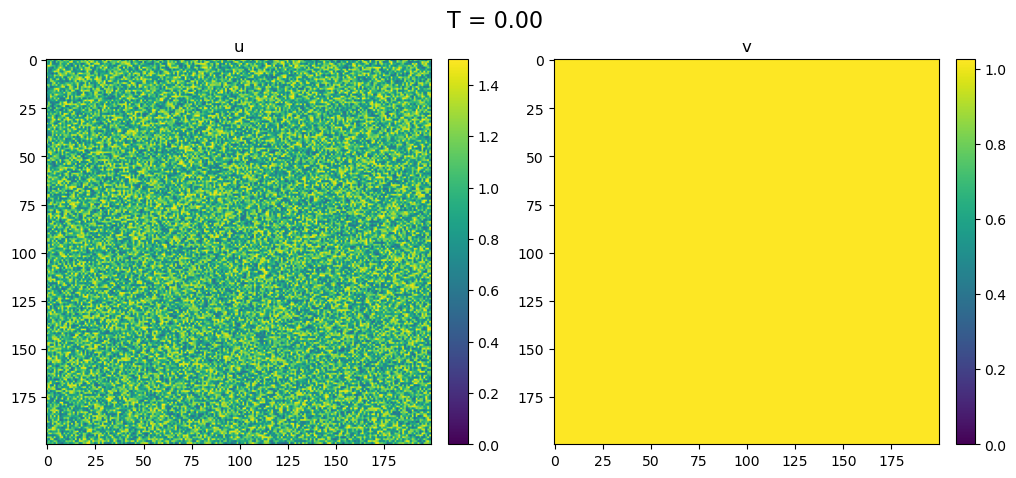

In [6]:
# Load and prune final model
model.load(f"{dir_name}/binn_best_val_model", device=device)

# Simulate surface
feql_u_array, feql_times = simulate_feql(training_data, model)
animate_uarray(feql_u_array, feql_times, f'{dir_name}/feql_sim')